# Generación de mercados
En este notebook nos proponemos simular diferentes mercados paramétricamente y posteriormente analizar esas simulaciones tomando como criterio el realismo de estos. Usaremos como generadores, en este primer análisis, un movimiento browniano geométrico y un Merton jump diffusion, teniendo en cuenta que hemos desarrollado código para ajustar estos dos modelos a los datos. Con cada uno de estos generadores, crearemos en primer lugar un mercado que denominaremos normal, como puede ser el de un índice bursátil, y por otro lado un mercado de alta volatilidad, como lo puede ser el precio de una criptomoneda.

Antes de entrar en la simulación concreta de cada tipo de modelo, enumeraremos algunas de las ventajas generales que proporciona tener un modelo realista de los datos.

1. Permite estimar el retorno medio y la volatilidad de los datos.
2. Estimar distribuciones de P&G de una estrategia antes de ejecutarla. Por lo tanto, permite calcular probabilidad de alcanzar un target o tocar un stop-loss.
3. Permite contextualizar métricas como el VaR o el Expected Shortfall, para la distribución de precios simulada.

Para cada modelo, además de las posibles particularidades de cada modelo, analizaremos estos tres puntos contextualizados a cada modelo. Para 

## Movimiento browniano geométrico
En el notebook ```simulaciones.ipynb``` está la especificación del modelo y el la concreción del método de máxima verosimilitud para su ajuste a una serie de datos. Aquí, además de generar una simulación de mercado usando un generador ajustado a un mercado, como decimos, normal; subrallaremos propiedades de este tipo de modelo a tener en cuenta.

La primera observación que realizamos sobre este tipo de modelo es que la ecuación que define el modelo puede ser resuelta analíticamente, esto es, hay una formula para $S_t$:
$$S_t = S_0\exp\left(\left(\mu - \frac{\sigma^2}{2}\right)t + \sigma B_t\right).$$

De esta forma, la distribución de $S_t$ es conocida: se trata de una variable log-normal de media $\mathbb{E}[S_t] = S_0e^{\mu t}$, por lo que, en este modelo, estamos asumiendo que los precios de media siguen una curva exponencial. La expresión para la varianza es conocida, pero algo complicada. En todo caso, subrallamos que esta crece de forma exponencial con el paso del tiempo, lo cual supone un problema a la hora de realizar predicciones a largo plazo.

Hay otra forma de plantear lo anterior: en lugar de precios podemos analizar las propiedades de los retornos: $r_{t} = \log(S_{t+\Delta t}/S_t)$. En este caso sabemos que la ecuación que define $r_t$ es
$$ d\log(S_t) = \mu dt + \sigma dB_t. $$
En este caso $r_{t}$ sigue una distribución normal de media $\mu\Delta t$ y varianza $\sigma^2 \Delta t$. Es decir la distribución de los retornos es constante en el tiempo, a diferencia de la de los precios.

### Estimación de media y varianza

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import datos
import SimulacionMonteCarlo

In [2]:
dd = datos.StockDataDownloader(source='fmp')
sp500 = dd.download("^GSPC")['close']

gbm = SimulacionMonteCarlo.GBM()
gbm.ajustar_parametros(sp500.values, M=100)
gbm.mostrar_parametros()

/home/jordi/Documents/educacio/master_unir/practicas/codigo/SimulacionMonteCarlo.py:130: RuntimeWarning: invalid value encountered in log
  nlL = -np.sum([np.log(1/(np.sqrt(2*np.pi*new_params['Deltat'])*var_sigma))


Ajuste de parámetros realizado correctamente.
===== Parámetros del modelo =====
T:		1255
N:		1255
Deltat:		1.0
S0:		4167.59
M:		100
mu:		0.0004934336605021035
sigma:		0.010666877026923125


Obtenemos un retorno medio de 0,0004, y una desviación estándar de los retornos de 0,0106. Esto nos indica que el precio del activo tiene tendencia a crecer, aunque no mucho. Anualizado, esto supone un retorno medio del 10% y una desviación estándar del 16,82%.

### Simulación de P&G
En primer lugar simulamos los precios con los parámetros mostrados anteriormente.

/tmp/ipykernel_4603/3230461547.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


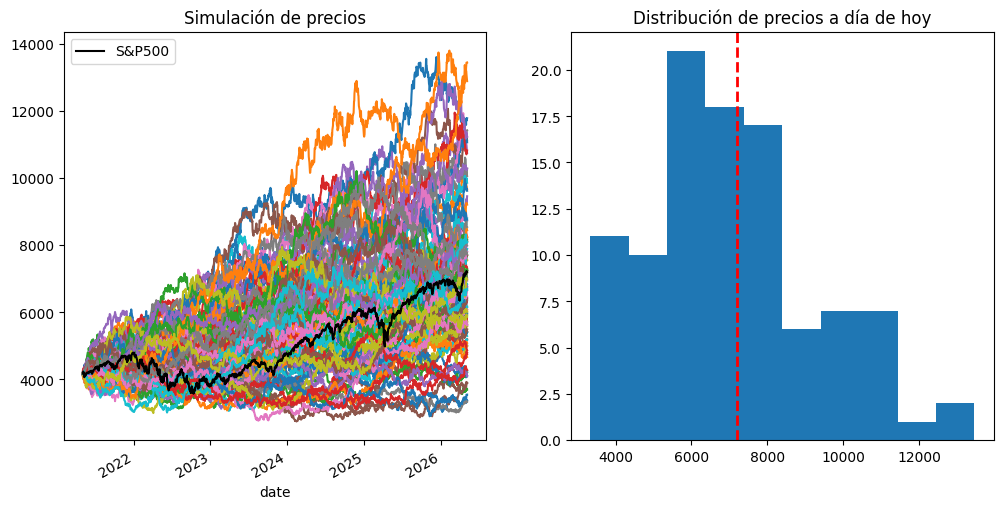

In [3]:
fig, axes = plt.subplots(1,2, figsize=(12,6))

simulation = gbm.simular()[:-1, :]
simulation_df = pd.DataFrame(simulation, index=sp500.index)
simulation_df.plot(legend=False, ax=axes[0])

sp500.name = 'S&P500'
sp500.plot(legend=True,ax=axes[0], color='black')
axes[0].set_title('Simulación de precios')

axes[1].hist(x=simulation[-1, :])
axes[1].axvline(x=sp500.values[-1], color='red', linestyle='--', linewidth=2, label='Último precio real')
axes[1].set_title('Distribución de precios a día de hoy')

fig.show()

En el primer gráfico se muestra el resultado de ejecutar 100 simulaciones con los parámetros ajustados a los datos del sp500 desde el 23 de abril de 2021 hasta hoy, 22 de abril de 2026. Junto con la distribución del precio a día de hoy (según el modelo), nos permite tener una idea intuitiva del significado del parámetro $\sigma$. 

Seguidamente calculamos el vector de P&G a partir de esta simulación. Consideraremos una inversión de USD 1 000 000 en el S&P500. Podríamos generar la variable retorno directamente, pero lo haremos a partir de la simulación para luego replicar el método con otros modelos.

                   0
count  125400.000000
mean      443.342086
std     10640.346633
min    -48808.663841
25%     -6724.534932
50%       466.956370
75%      7600.207906
max     47079.201281


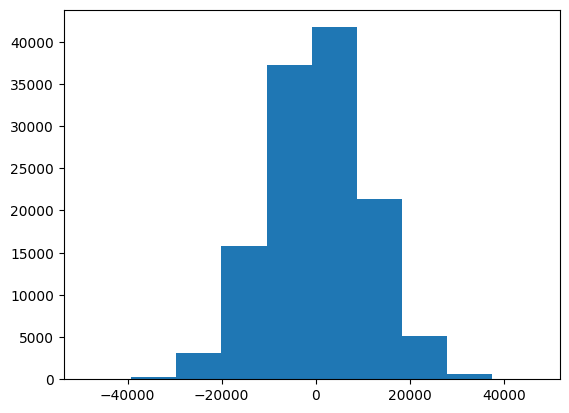

In [4]:
returns = np.diff(np.log(simulation), axis=0).flatten()
PandG = 1_000_000 * (np.exp(returns) - 1)
print(pd.DataFrame(PandG).describe())
plt.hist(PandG)
plt.show()


Como hemos dichos, los retornos siguen una distribución normal, con la media y varianza que hemos considerado anteriormente. El retorno de una inversión de USD 1 000 000 para un día de horizonte temporal puede oscilar en una pérdida o ganancia de casi USD 50 000. La ganancia que esperamos tener es de USD 468 en un día.


### VaR y Expected Shortfall
Calculamos el VaR al 5\% para horizonte temporal de 1 día y el Expected Shortfall para esta simulación de P&G. Recordamos que estas son métricas para el control del riesgo que nos indican respectívamente que solo en un 5% de los casos vamos a tener caídas superiores al VaR (definición de VaR), y la media de las caídas superiores al VaR (definición de Expected Shortfall).

In [5]:
VaR_gbm = np.percentile(PandG, 0.05)
ES_gbm = np.mean(PandG[PandG < VaR_gbm])
print("VaR: {}".format(VaR_gbm))
print("Expected Shortfall: {}".format(ES_gbm))

VaR: -34617.48325146517
Expected Shortfall: -37469.674204202405


Observamos que el Expected Shortfall y el VaR no difieren en exceso, esto nos indica que la cola de pérdidas de la distribución no es excesivamente pronunciada (esto es conocido para la distribución normal).

## Merton Jump Diffusion
Pasamos a analizar un modelo tipo Merton Jump Diffusion, el cual es una variación del movimiento browniano geométrico en el que hemos añadido saltos aleatorios. La frecuencia y la magnitud de los saltos se aprende de los datos, como los otros parámetros. En este caso la distribución de los precios no es log-normal, ya que intervienen los saltos, que aumentan la varianza del precio.

Para demostrar el modelo, usaremos el precio del hierro en dólares, uno de los bienes más afectados por la actual guerra en Irán.

In [6]:
import importlib
importlib.reload(SimulacionMonteCarlo)
dd = datos.StockDataDownloader(source='eodhd')
iron = dd.download("IRON.US")['close']

mjd = SimulacionMonteCarlo.MertonJumpDiffusion()
mjd.ajustar_parametros(iron.values, M=100)
mjd.mostrar_parametros()

===== Parámetros del modelo =====
T:		250
N:		250
Deltat:		1.0
S0:		48.6
M:		100
mu:		0.0025836939378544132
sigma:		0.02329326549990542
lambda:		0.04661298594155286
mu_J:		-0.027882125788836684
sigma_J:	0.11738800238014394


/tmp/ipykernel_4603/3647686622.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


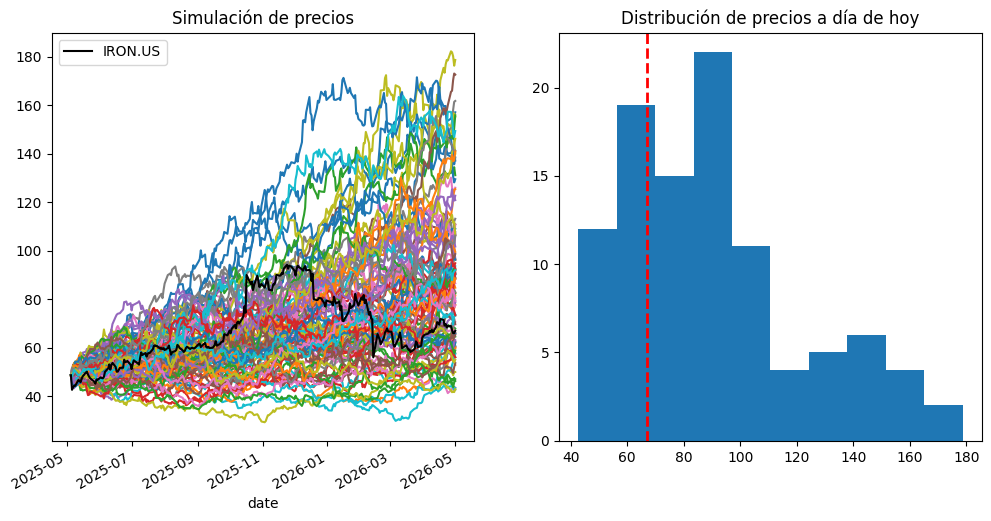

In [7]:
fig, axes = plt.subplots(1,2, figsize=(12,6))

simulation = mjd.simular()[:-1, :]
simulation_df = pd.DataFrame(simulation, index=iron.index)
simulation_df.plot(legend=False, ax=axes[0])

iron.name = 'IRON.US'
iron.plot(legend=True,ax=axes[0], color='black')
axes[0].set_title('Simulación de precios')

axes[1].hist(x=simulation[-1, :])
axes[1].axvline(x=iron.values[-1], color='red', linestyle='--', linewidth=2, label='Último precio real')
axes[1].set_title('Distribución de precios a día de hoy')

fig.show()

### Estimación de media y varianza
Aunque obtenemos valores para $\mu$ y $\sigma$, estos no se corresponden con la media de los precios o de los retornos: debemos estimarlos a partir de los datos.

In [8]:
returns_iron = np.diff(np.log(iron), axis=0).flatten()
print("Media de retornos {:.4f}".format(np.mean(returns_iron)))
print("Desvest de retornos {:.4f}".format(np.std(returns_iron)))

Media de retornos 0.0013
Desvest de retornos 0.0349


Anualizado, obtenemos un retorno medio del 40% pero una desviación estándar del 55%. Lo cual es coherente con el conocido binomio riesgo-rentabilidad: a mayor rentabilidad esperada, mayor riesgo hay que asumir. 

### Simulación de P&G
En la siguiente simulación podemos observar como en esta distribución la colas están mucho más presentes de lo que esperaríamos en una variable distribuída normalmente.

                   0
count     249.000000
mean     1888.646235
std     34653.963440
min   -219120.725750
25%    -16151.596083
50%      1763.103061
75%     16821.447345
max    209521.247983


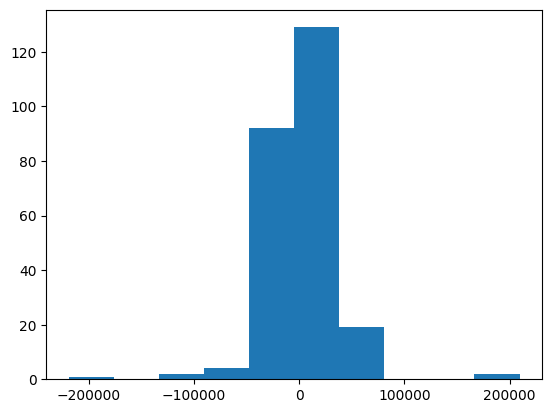

In [9]:
PandG_iron = 1_000_000 * (np.exp(returns_iron) - 1)
print(pd.DataFrame(PandG_iron).describe())
plt.hist(PandG_iron)
plt.show()

### VaR y Expected Shortfall
Finalmente calculamos un VaR y un Expected Shortfall de las mismas características que en el caso anterior, pero con esta nueva distribución de retornos. Observamos que el VaR es marcadamente mayor en valor absoluto, pasando de USD 34000 a más de USD 200000, lo cual supone un salto más que significativo.
Observamos también que la diferencia entre estas dos métricas en éste caso es más marcada: la diferencia es de unos USD 12000, un orden de magnitud mayor que en el otro caso.

In [10]:
VaR_mjd = np.percentile(PandG_iron, 0.05)
ES_mjd = np.mean(PandG_iron[PandG_iron < VaR_mjd])
print("VaR: {:.4f}".format(VaR_mjd))
print("Expected Shortfall: {:.4f}".format(ES_mjd))

VaR: -207322.1837
Expected Shortfall: -219120.7258
